**Project Title:** Loan Default Prediction and Credit Risk Analytics 

**Domain:** FinTech, Retail Banking, and Risk Management

**Primary Target Variable:** Loan_Status (A binary column where 0 means the borrower successfully repaid the loan, and 1 means the borrower defaulted)

**Core Goal:** The main objective of this project is to take raw, messy financial data, clean up all the errors and missing values, engineer smart risk features, and build a machine learning model to accurately predict whether a new loan applicant is likely to default. This helps banks minimize financial losses while safely approving reliable customers.

## Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("Loan_Default_RAW_Uncleaned.csv")

## Data Understanding

In [4]:
df.shape

(1505, 12)

In [5]:
df.head()

,Customer_ID,Age,Annual_Income,Employment_Length_Yrs,Home_Ownership,Credit_Score,Debt_To_Income_Ratio,Loan_Amount,Loan_Intent,Interest_Rate,Loan_Grade,Loan_Status
0,CUST-10000,22,"$27,997.70",2 years,mortgage,636,11.36%,"$9,000",Home Improvement,14.82%,D,0
1,CUST-10001,27,"$62,076.19",9 years,mortgage,696,14.54%,"$17,500",medical,11.36%,C,0
2,CUST-10002,47,"$122,165.73",NaN,OWN,708,11.57%,"$2,500",Personal,12.18%,B,0
3,CUST-10003,34,"$55,721.03",0 year,mortgage,700,6.92%,"$9,500",Personal,12.15%,B,0
4,CUST-10004,34,"$72,848.88",5 years,mortgage,721,21.83%,"$4,500",EDUCATION,12.58%,B,0


In [6]:
df.sample(5)

,Customer_ID,Age,Annual_Income,Employment_Length_Yrs,Home_Ownership,Credit_Score,Debt_To_Income_Ratio,Loan_Amount,Loan_Intent,Interest_Rate,Loan_Grade,Loan_Status
342,CUST-10342,30,"$90,476.50",3 years,OWN,661,14.66%,"$12,500",Home Improvement,13.26%,C,0
1503,CUST-10100,55,NaN,22 years,OWN,696,10.19%,"$6,000",medical,10.83%,C,0
802,CUST-10802,44,"$86,550.71",5 years,mortgage,717,25.2%,"$18,000",EDUCATION,12.41%,B,0
1373,CUST-11373,67,"$117,365.22",0 year,mortgage,648,27.89%,"$10,000",Personal,16.21%,D,0
120,CUST-10120,29,"$65,761.67",10 years,Rent,823,23.27%,"$7,500",Debt Consolidation,7.79%,A,0


In [7]:
df.tail()

,Customer_ID,Age,Annual_Income,Employment_Length_Yrs,Home_Ownership,Credit_Score,Debt_To_Income_Ratio,Loan_Amount,Loan_Intent,Interest_Rate,Loan_Grade,Loan_Status
1500,CUST-10005,50,"$120,820.06",7 years,OWN,693,23.91%,"$16,500",EDUCATION,11.17%,C,0
1501,CUST-10012,142,"$111,789.81",1 year,mortgage,652,27.48%,"$8,500",Personal,14.41%,C,0
1502,CUST-10045,-5,"$105,684.29",0 year,mortgage,727,24.04%,"$8,000",EDUCATION,13.19%,B,0
1503,CUST-10100,55,NaN,22 years,OWN,696,10.19%,"$6,000",medical,10.83%,C,0
1504,CUST-10100,55,NaN,22 years,OWN,696,10.19%,"$6,000",medical,10.83%,C,0


## Understand the Structure

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1505 entries, 0 to 1504
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Customer_ID            1505 non-null   object
 1   Age                    1505 non-null   int64 
 2   Annual_Income          1377 non-null   object
 3   Employment_Length_Yrs  1346 non-null   object
 4   Home_Ownership         1505 non-null   object
 5   Credit_Score           1505 non-null   int64 
 6   Debt_To_Income_Ratio   1505 non-null   object
 7   Loan_Amount            1505 non-null   object
 8   Loan_Intent            1505 non-null   object
 9   Interest_Rate          1413 non-null   object
 10  Loan_Grade             1505 non-null   object
 11  Loan_Status            1505 non-null   int64 
dtypes: int64(3), object(9)
memory usage: 141.2+ KB


====> As we can see above, some columns has missing values and incorrect data types. 

### Finding Duplicate Records

In [9]:
df.duplicated().sum()

np.int64(5)

====> There are 5 duplicates present in the data frame. Lets drop these duplicates.

In [10]:
df = df.drop_duplicates()

In [11]:
print("Remaining Rows & Columns after dropping duplicates:",df.shape)

Remaining Rows & Columns after dropping duplicates: (1500, 12)


In [12]:
#Finding column names & missing values
df.columns

Index(['Customer_ID', 'Age', 'Annual_Income', 'Employment_Length_Yrs',
       'Home_Ownership', 'Credit_Score', 'Debt_To_Income_Ratio', 'Loan_Amount',
       'Loan_Intent', 'Interest_Rate', 'Loan_Grade', 'Loan_Status'],
      dtype='object')

In [13]:
df.isnull().sum()

Customer_ID                0
Age                        0
Annual_Income            126
Employment_Length_Yrs    159
Home_Ownership             0
Credit_Score               0
Debt_To_Income_Ratio       0
Loan_Amount                0
Loan_Intent                0
Interest_Rate             92
Loan_Grade                 0
Loan_Status                0
dtype: int64

--> Annual income, Employment length yrs and Interest rate columns have missing values.

--> Change the data type of those columns that have incorrect data types, fill the missing values, and replace characters.

#### Finding invalid values, Replacing Characters, filling missing values by visualizing graphs, & Changing the data types of the columns that have incorrect data types

In [14]:
df["Age"] = np.where((df["Age"] < 0) | (df["Age"] > 100), np.nan, df["Age"])

In [15]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [16]:
df["Age"].isna().sum()

np.int64(0)

In [17]:
df["Annual_Income"] = pd.to_numeric(df["Annual_Income"].astype(str).str.strip().str.replace(r"[$,]","",regex= "True"),errors = "coerce")

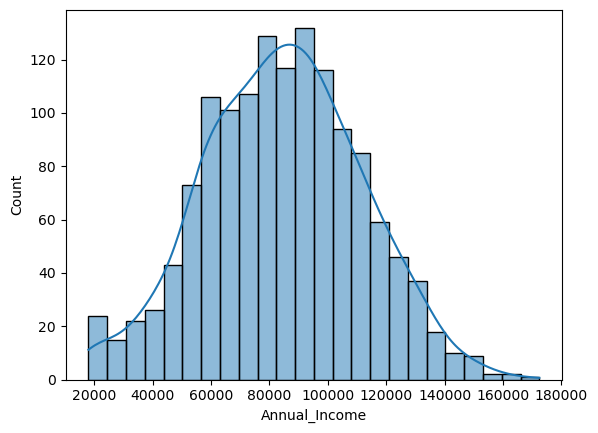

In [18]:
sns.histplot(data = df["Annual_Income"], kde = True)
plt.show()

In [19]:
df["Annual_Income"] = df["Annual_Income"].fillna(df["Annual_Income"].median())

In [20]:
df["Annual_Income"].isna().sum()

np.int64(0)

In [21]:
df["Employment_Length_Yrs"] = pd.to_numeric(df["Employment_Length_Yrs"].astype(str).str.extract(r"(\d+)",expand = False), errors = "coerce")

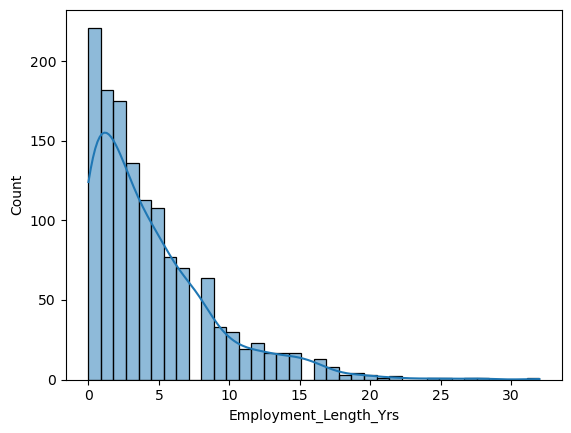

In [22]:
sns.histplot(data = df["Employment_Length_Yrs"], kde = True)
plt.show()

In [23]:
df["Employment_Length_Yrs"] = df["Employment_Length_Yrs"].fillna(df["Employment_Length_Yrs"].median())

In [24]:
df["Employment_Length_Yrs"].isna().sum()

np.int64(0)

In [25]:
df["Interest_Rate"] = pd.to_numeric(df["Interest_Rate"].astype(str).str.replace("%",""), errors = "coerce")

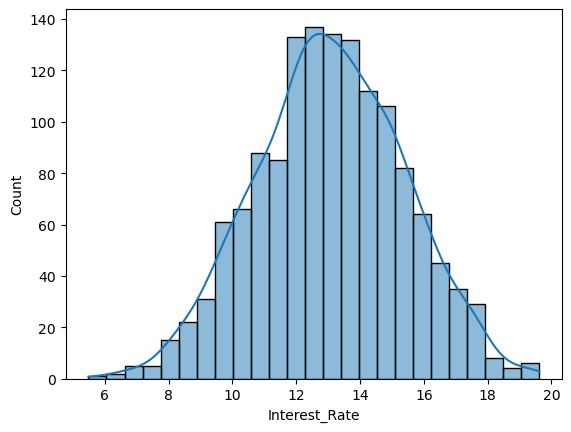

In [26]:
sns.histplot(data = df["Interest_Rate"], kde = True)
plt.show()

In [27]:
df["Interest_Rate"] = df["Interest_Rate"].fillna(df["Interest_Rate"].median())

In [28]:
df["Interest_Rate"].isnull().sum()

np.int64(0)

In [29]:
df["Home_Ownership"] = df["Home_Ownership"].str.strip().str.title()

In [30]:
df["Debt_To_Income_Ratio"] = pd.to_numeric(df["Debt_To_Income_Ratio"].str.replace("%",""),errors = "coerce")

In [31]:
df["Loan_Amount"] = pd.to_numeric(df["Loan_Amount"].str.replace(r"[$,]","",regex = True), errors = "coerce")

In [32]:
df["Loan_Intent"] = df["Loan_Intent"].str.strip().str.title()

#### checking the [data structure] after correcting the data types, removing duplicates & invalid characters, filling missing values

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            1500 non-null   object 
 1   Age                    1500 non-null   float64
 2   Annual_Income          1500 non-null   float64
 3   Employment_Length_Yrs  1500 non-null   float64
 4   Home_Ownership         1500 non-null   object 
 5   Credit_Score           1500 non-null   int64  
 6   Debt_To_Income_Ratio   1500 non-null   float64
 7   Loan_Amount            1500 non-null   int64  
 8   Loan_Intent            1500 non-null   object 
 9   Interest_Rate          1500 non-null   float64
 10  Loan_Grade             1500 non-null   object 
 11  Loan_Status            1500 non-null   int64  
dtypes: float64(5), int64(3), object(4)
memory usage: 152.3+ KB


### Seperating Numerical & Categorical columns

In [34]:
num_cols = df.select_dtypes(include = ["int","float"]).columns
print(num_cols)

Index(['Age', 'Annual_Income', 'Employment_Length_Yrs', 'Credit_Score',
       'Debt_To_Income_Ratio', 'Loan_Amount', 'Interest_Rate', 'Loan_Status'],
      dtype='object')


In [35]:
cat_cols = df.select_dtypes(include = ["object"]).columns
print(cat_cols)

Index(['Customer_ID', 'Home_Ownership', 'Loan_Intent', 'Loan_Grade'], dtype='object')


### Distribution of all numerical variables

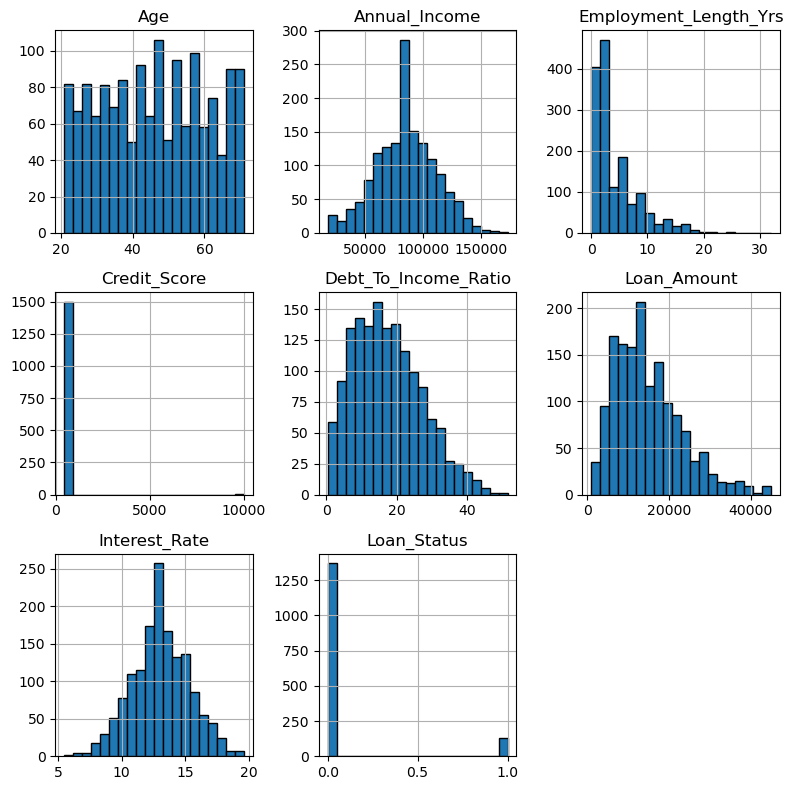

In [36]:
df[num_cols].hist(figsize = (8,8), edgecolor = "black", bins = 20)
plt.tight_layout()
plt.show()

### Boxplot of all columns

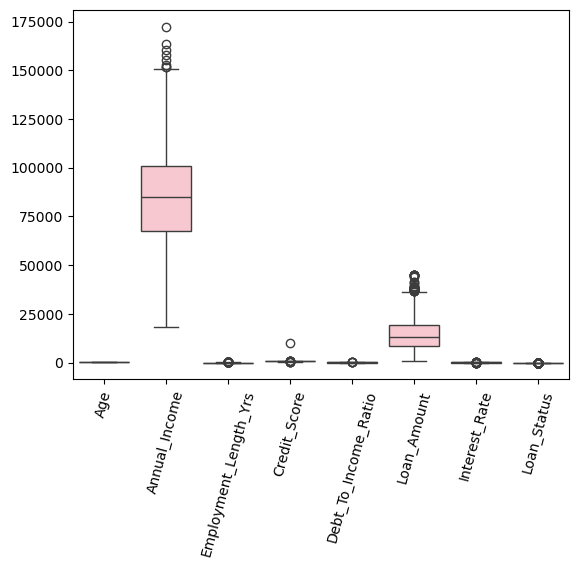

In [37]:
#boxplot of all columns before treating outliers
sns.boxplot(data = df, color = "pink")
plt.xticks(rotation = 75)
plt.show()

## Univariate Analysis

### Numerical Analysis

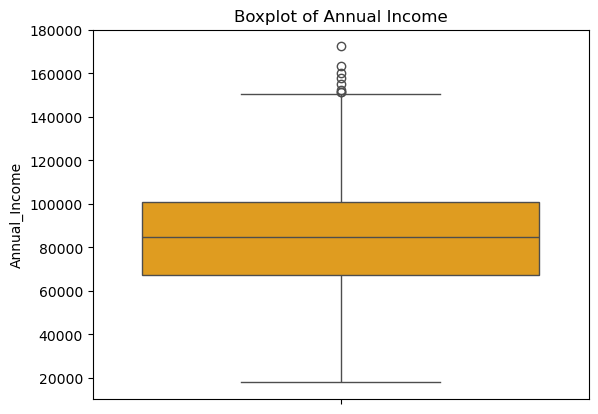

In [38]:
sns.boxplot(y = df["Annual_Income"], color = "orange")
plt.title("Boxplot of Annual Income")
plt.show()

**INSIGHTS**
- As we can see in the above boxplot that has some outliers on the upper whisker that shows there are few people that have high annual income.

In [39]:
Q1 = df["Annual_Income"].quantile(0.25)
Q3 = df["Annual_Income"].quantile(0.75)
IQR = Q3-Q1
upper_whisker = Q3 + 1.5 * IQR
df["Annual_Income"] = np.where(df["Annual_Income"] > upper_whisker, upper_whisker, df["Annual_Income"])

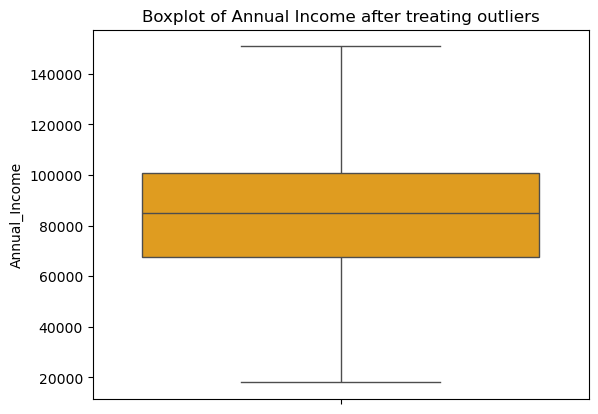

In [40]:
sns.boxplot(y = df["Annual_Income"], color = "orange")
plt.title("Boxplot of Annual Income after treating outliers")
plt.show()

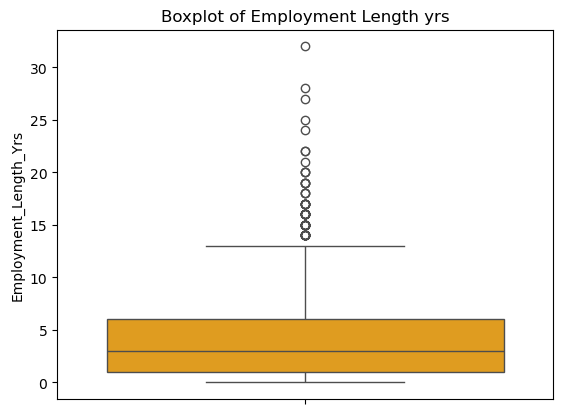

In [41]:
sns.boxplot(y = df["Employment_Length_Yrs"], color = "orange")
plt.title("Boxplot of Employment Length yrs")
plt.show()

In [42]:
Q1 = df["Employment_Length_Yrs"].quantile(0.25)
Q3 = df["Employment_Length_Yrs"].quantile(0.75)
IQR = Q3-Q1
upper_whisker = Q3 + 1.5 * IQR
df["Employment_Length_Yrs"] = np.where(df["Employment_Length_Yrs"] > upper_whisker, upper_whisker, df["Employment_Length_Yrs"])

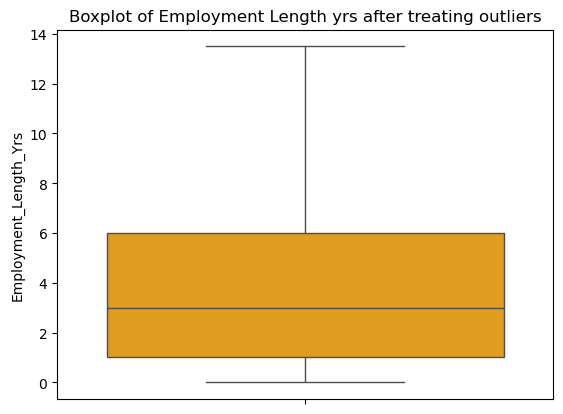

In [43]:
sns.boxplot(y = df["Employment_Length_Yrs"], color = "orange")
plt.title("Boxplot of Employment Length yrs after treating outliers")
plt.show()

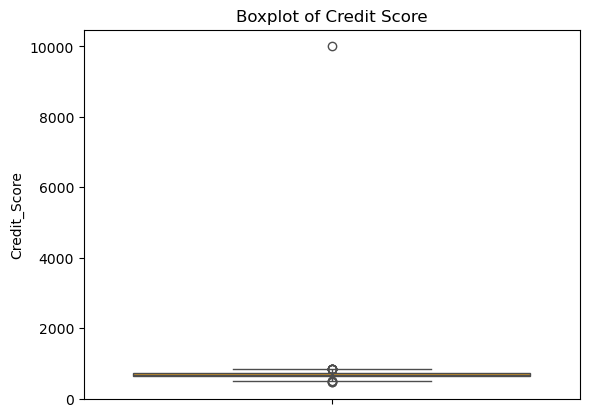

In [44]:
sns.boxplot(y = df["Credit_Score"], color = "orange")
plt.title("Boxplot of Credit Score")
plt.show()

In [45]:
Q1 = df["Credit_Score"].quantile(0.25)
Q3 = df["Credit_Score"].quantile(0.75)
IQR = Q3-Q1
upper_whisker = Q3 + 1.5 * IQR
lower_whisker = Q1 - 1.5 * IQR
df["Credit_Score"] = np.where(df["Credit_Score"] > upper_whisker, upper_whisker, df["Credit_Score"])
df["Credit_Score"] = np.where(df["Credit_Score"] < lower_whisker, lower_whisker, df["Credit_Score"])

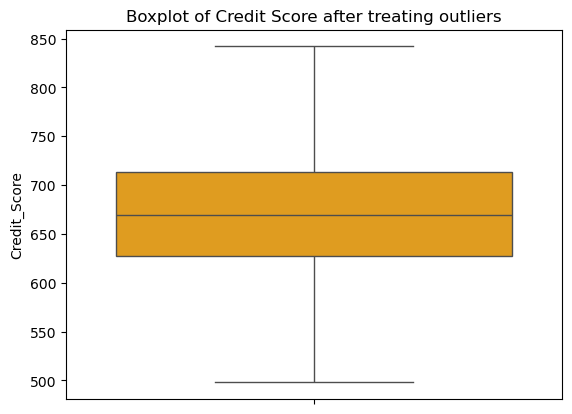

In [46]:
sns.boxplot(y = df["Credit_Score"], color = "orange")
plt.title("Boxplot of Credit Score after treating outliers")
plt.show()

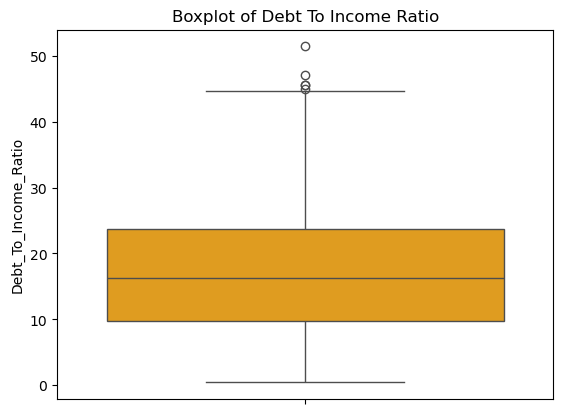

In [47]:
sns.boxplot(y = df["Debt_To_Income_Ratio"], color = "orange")
plt.title("Boxplot of Debt To Income Ratio")
plt.show()

In [48]:
Q1 = df["Debt_To_Income_Ratio"].quantile(0.25)
Q3 = df["Debt_To_Income_Ratio"].quantile(0.75)
IQR = Q3-Q1
upper_whisker = Q3 + 1.5 * IQR
df["Debt_To_Income_Ratio"] = np.where(df["Debt_To_Income_Ratio"] > upper_whisker, upper_whisker, df["Debt_To_Income_Ratio"])

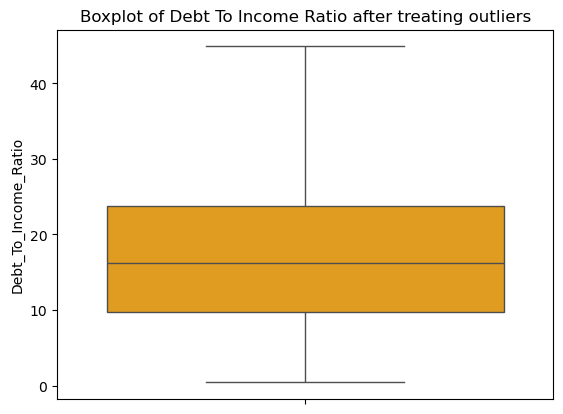

In [49]:
sns.boxplot(y = df["Debt_To_Income_Ratio"], color = "orange")
plt.title("Boxplot of Debt To Income Ratio after treating outliers")
plt.show()

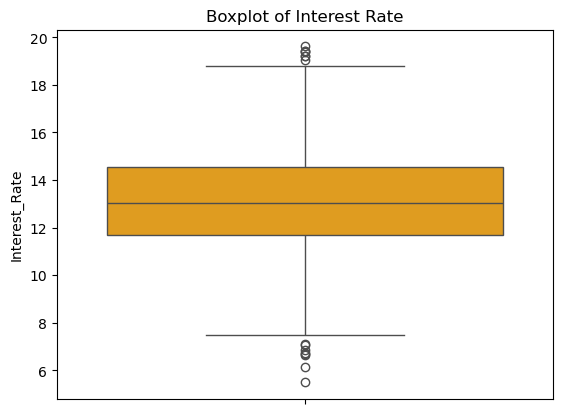

In [50]:
sns.boxplot(y = df["Interest_Rate"], color = "orange")
plt.title("Boxplot of Interest Rate")
plt.show()

In [51]:
Q1 = df["Interest_Rate"].quantile(0.25)
Q3 = df["Interest_Rate"].quantile(0.75)
IQR = Q3-Q1
upper_whisker = Q3 + 1.5 * IQR
lower_whisker = Q1 - 1.5 * IQR
df["Interest_Rate"] = np.where(df["Interest_Rate"]<lower_whisker, lower_whisker, df["Interest_Rate"])
df["Interest_Rate"] = np.where(df["Interest_Rate"]>upper_whisker, upper_whisker, df["Interest_Rate"])

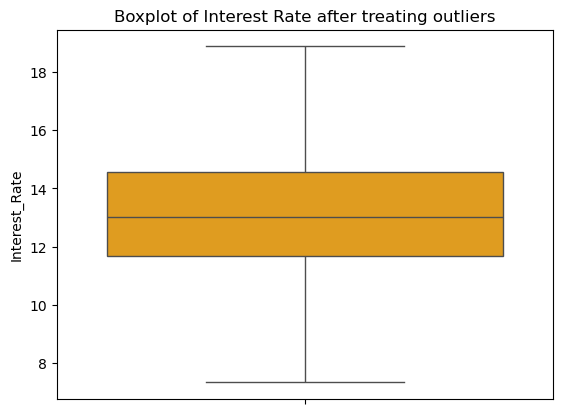

In [52]:
sns.boxplot(y = df["Interest_Rate"], color = "orange")
plt.title("Boxplot of Interest Rate after treating outliers")
plt.show()

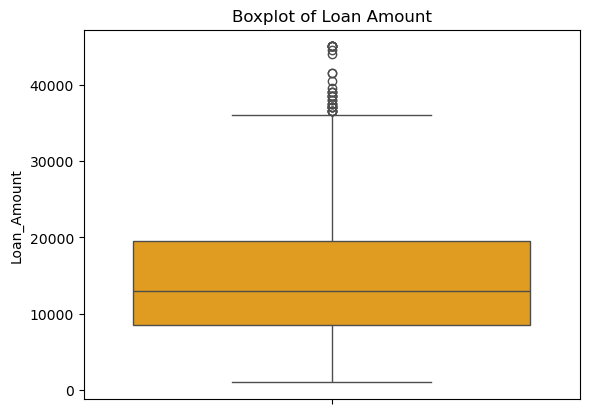

In [53]:
sns.boxplot(y = df["Loan_Amount"], color = "orange")
plt.title("Boxplot of Loan Amount")
plt.show()

In [54]:
Q1 = df["Loan_Amount"].quantile(0.25)
Q3 = df["Loan_Amount"].quantile(0.75)
IQR = Q3-Q1
upper_whisker = Q3 + 1.5 * IQR
df["Loan_Amount"] = np.where(df["Loan_Amount"]>upper_whisker, upper_whisker, df["Loan_Amount"])

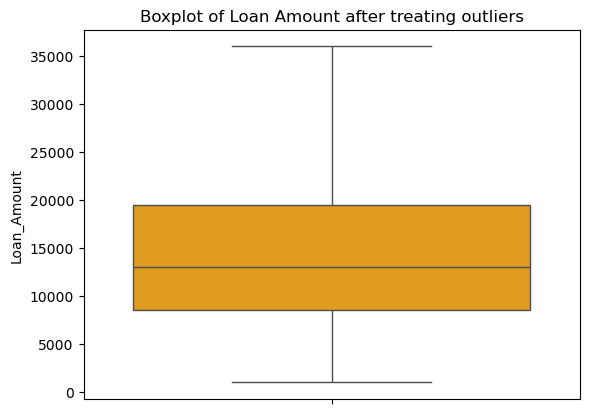

In [55]:
sns.boxplot(y = df["Loan_Amount"], color = "orange")
plt.title("Boxplot of Loan Amount after treating outliers")
plt.show()

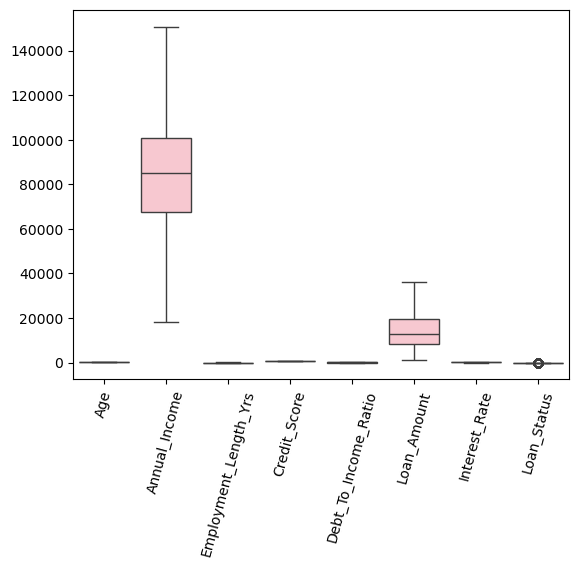

In [56]:
#boxplot of all columns after treating outliers
sns.boxplot(data = df, color = "pink")
plt.xticks(rotation = 75)
plt.show()

In [57]:
df.describe()

,Age,Annual_Income,Employment_Length_Yrs,Credit_Score,Debt_To_Income_Ratio,Loan_Amount,Interest_Rate,Loan_Status
count,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,45.858667,84520.83714,4.107667,669.117333,17.296347,14678.666667,13.063000,0.086667
std,14.574921,25792.43422,3.697615,64.093355,9.595992,7926.598611,2.229067,0.281440
min,21.000000,18000.00000,0.000000,498.000000,0.430000,1000.000000,7.340000,0.000000
25%,33.000000,67541.87250,1.000000,627.000000,9.690000,8500.000000,11.667500,0.000000
50%,46.000000,84994.73000,3.000000,669.000000,16.205000,13000.000000,13.030000,0.000000
75%,58.000000,100856.78500,6.000000,713.000000,23.770000,19500.000000,14.552500,0.000000
max,71.000000,150829.15375,13.500000,842.000000,44.890000,36000.000000,18.880000,1.000000


### Distribution of all numerical variables

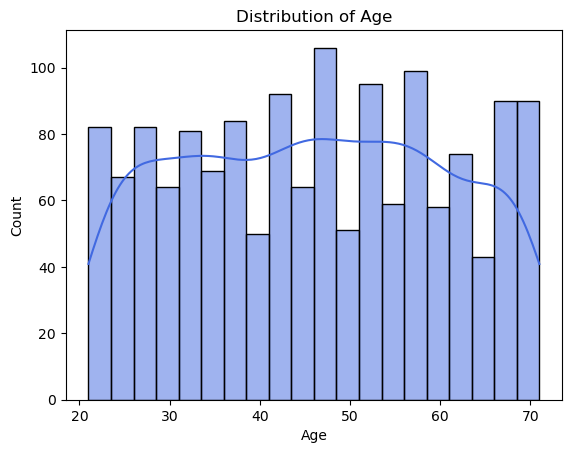

In [58]:
sns.histplot(df["Age"], kde = True, bins = 20, color = "royalblue")
plt.title("Distribution of Age")
plt.show()

**INSIGHTS:**
- As we can see in the above plot, we plot the age and mostly the age lie between 21-71 who takes a loan.
- The graph is normaly distributed means there is no outlier present in the age column.

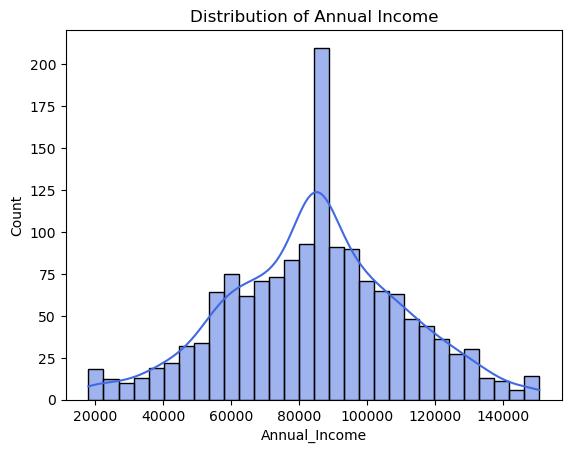

In [59]:
sns.histplot(x = df["Annual_Income"], bins = 30, kde = True, color = "royalblue")
plt.title("Distribution of Annual Income")
plt.show()

**INSIGHTS**

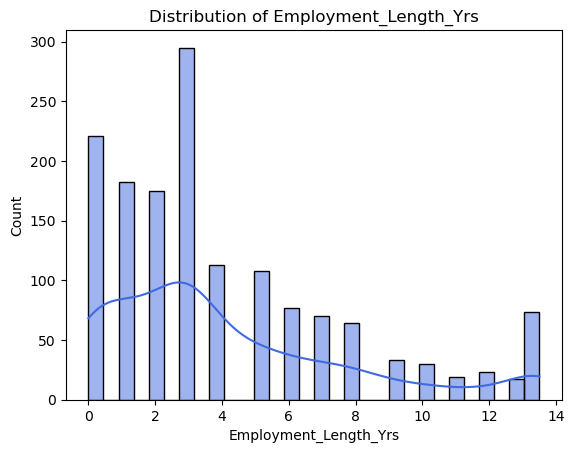

In [60]:
sns.histplot(x = df["Employment_Length_Yrs"], bins = 30, kde = True, color = "royalblue")
plt.title("Distribution of Employment_Length_Yrs")
plt.show()

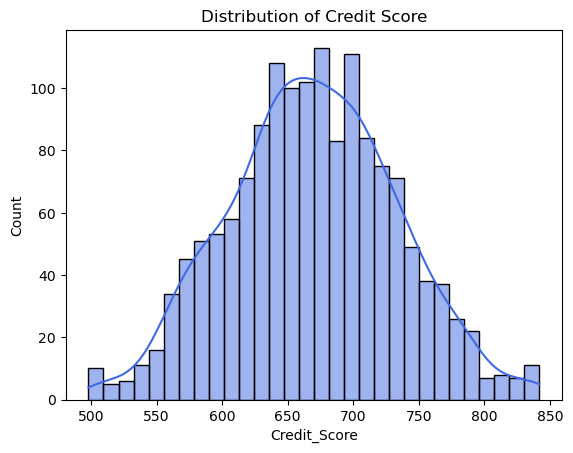

In [61]:
sns.histplot(x = df["Credit_Score"], bins = 30, kde = True, color = "royalblue")
plt.title("Distribution of Credit Score")
plt.show()

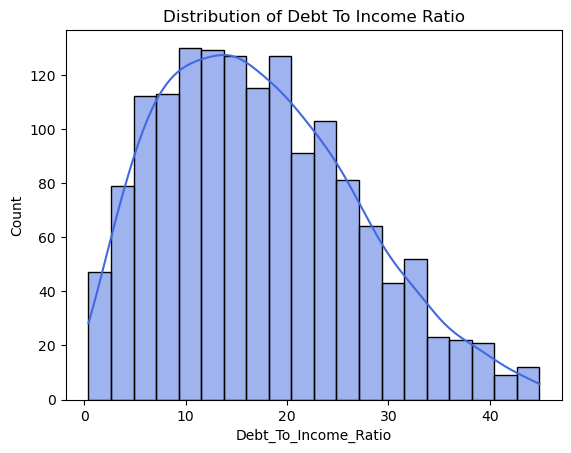

In [62]:
sns.histplot(data = df["Debt_To_Income_Ratio"], bins = 20, kde = True, color = "royalblue")
plt.title("Distribution of Debt To Income Ratio")
plt.show()

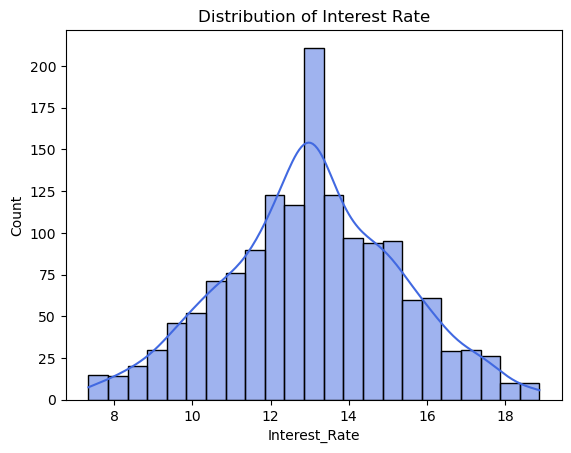

In [63]:
sns.histplot(df["Interest_Rate"], kde = True, color = "royalblue")
plt.title("Distribution of Interest Rate")
plt.show()

**INSIGHTS**

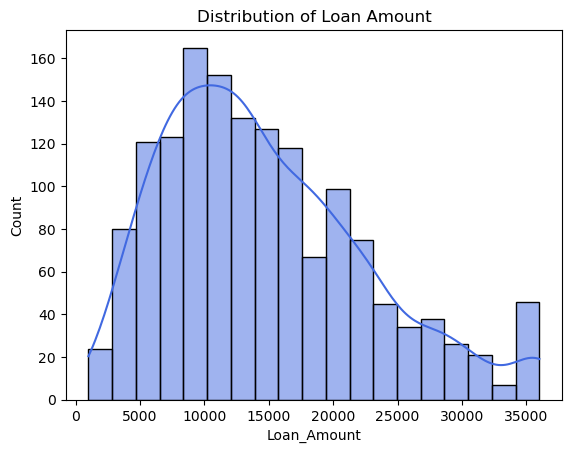

In [64]:
sns.histplot(df["Loan_Amount"], kde = True, color = "royalblue")
plt.title("Distribution of Loan Amount")
plt.show()

**INSIGHTS**

### Categorical analysis

In [65]:
df[cat_cols] 

,Customer_ID,Home_Ownership,Loan_Intent,Loan_Grade
0,CUST-10000,Mortgage,Home Improvement,D
1,CUST-10001,Mortgage,Medical,C
2,CUST-10002,Own,Personal,B
3,CUST-10003,Mortgage,Personal,B
4,CUST-10004,Mortgage,Education,B
...,...,...,...,...
1495,CUST-11495,Rent,Personal,C
1496,CUST-11496,Mortgage,Medical,A
1497,CUST-11497,Rent,Education,C
1498,CUST-11498,Mortgage,Personal,E


In [66]:
df["Home_Ownership"].value_counts()

Home_Ownership
Rent        679
Mortgage    579
Own         213
Other        29
Name: count, dtype: int64

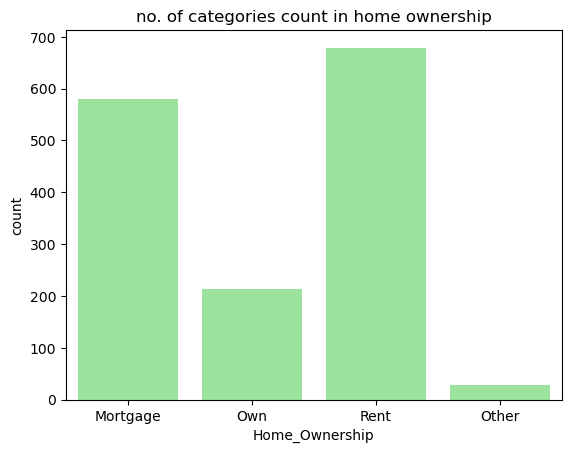

In [67]:
#Home Ownership Distribution
sns.countplot(x=df["Home_Ownership"], color = "lightgreen")
plt.title("no. of categories count in home ownership")
plt.show()

In [68]:
df["Loan_Intent"].value_counts()

Loan_Intent
Personal              426
Education             293
Medical               278
Venture               196
Debt Consolidation    159
Home Improvement      148
Name: count, dtype: int64

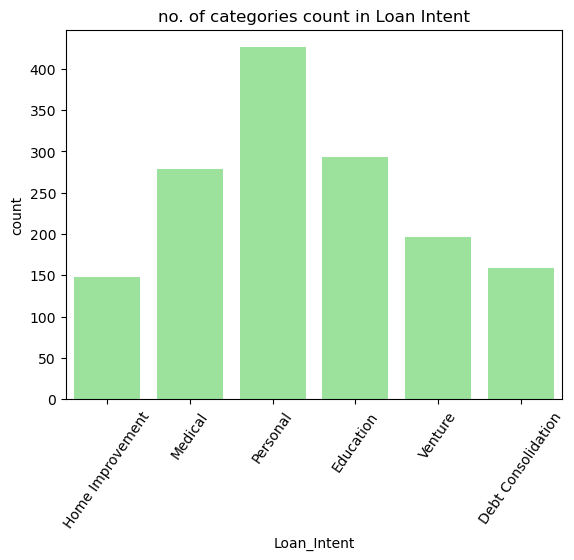

In [69]:
#Loan Intent Distribution
sns.countplot(x=df["Loan_Intent"], color = "lightgreen")
plt.title("no. of categories count in Loan Intent")
plt.xticks(rotation = 55)
plt.show()

In [70]:
df["Loan_Grade"].value_counts()

Loan_Grade
C    443
D    352
B    324
E    184
A    158
F     39
Name: count, dtype: int64

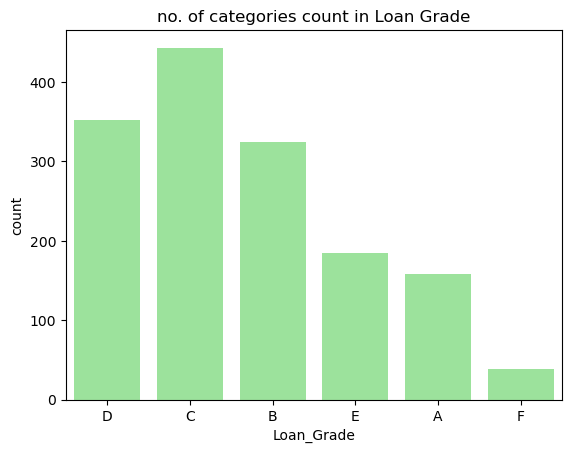

In [71]:
#Loan Grade Distribution
sns.countplot(x=df["Loan_Grade"], color = "lightgreen")
plt.title("no. of categories count in Loan Grade")
plt.show()

In [72]:
df["Loan_Status"].value_counts()

Loan_Status
0    1370
1     130
Name: count, dtype: int64

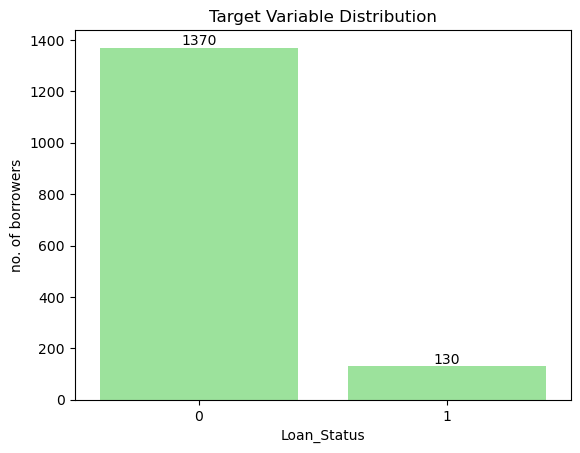

In [73]:
#Loan Status Distribution
ax = sns.countplot(x=df["Loan_Status"], color = "lightgreen")
ax.bar_label(ax.containers[0])
plt.title("Target Variable Distribution")
plt.ylabel("no. of borrowers")
plt.show()

## BIVARIATE ANALYSIS

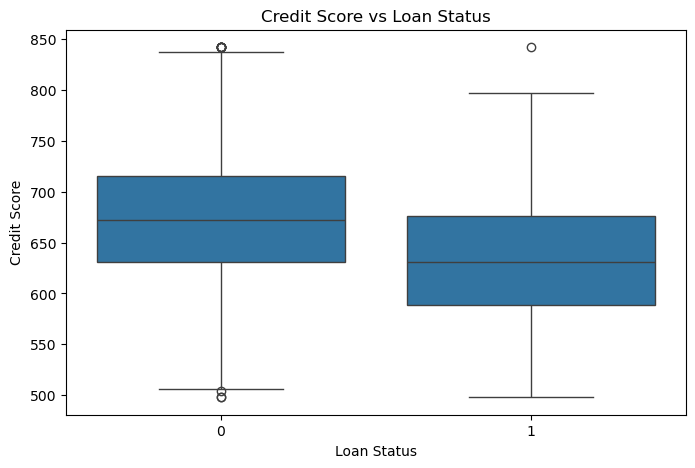

In [74]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Loan_Status", y="Credit_Score")

plt.title("Credit Score vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Credit Score")

plt.show()

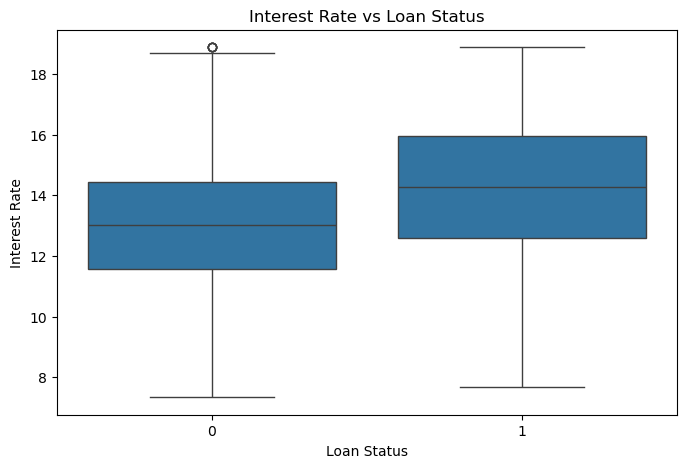

In [75]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Loan_Status", y="Interest_Rate")

plt.title("Interest Rate vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Interest Rate")

plt.show()

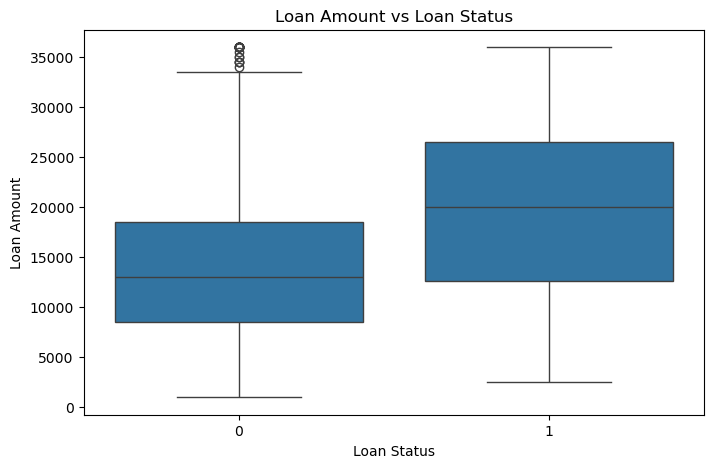

In [76]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Loan_Status", y="Loan_Amount")

plt.title("Loan Amount vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")

plt.show()

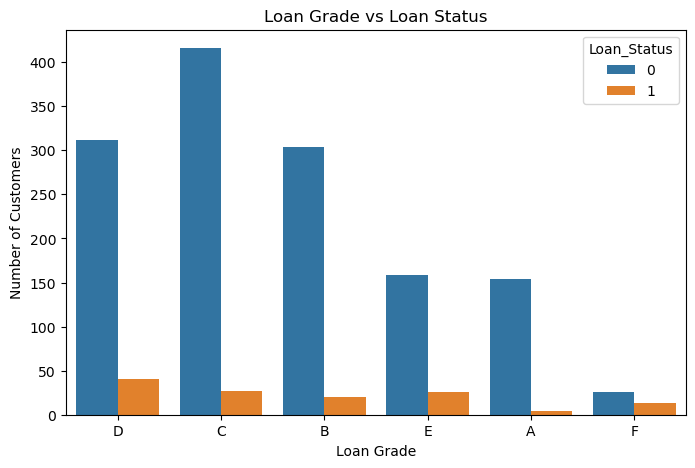

In [77]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Loan_Grade", hue="Loan_Status")

plt.title("Loan Grade vs Loan Status")
plt.xlabel("Loan Grade")
plt.ylabel("Number of Customers")

plt.show()

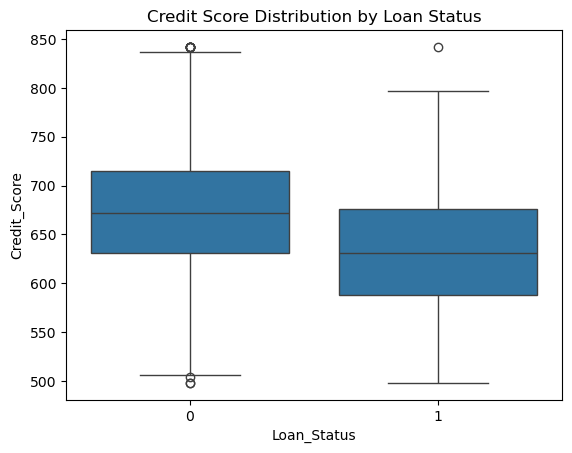

In [78]:
#Loan Status vs Credit Score 
sns.boxplot(x="Loan_Status", y="Credit_Score", data=df)
plt.title("Credit Score Distribution by Loan Status")
plt.show()

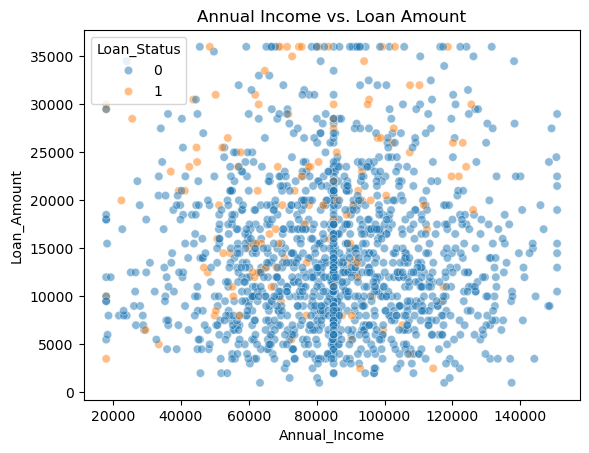

In [79]:
#scatter plot: Annual Income vs Loan Amount
sns.scatterplot(x='Annual_Income', y='Loan_Amount', data=df, alpha=0.5, hue = "Loan_Status")
plt.title('Annual Income vs. Loan Amount')
plt.show()

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Home Improvement'),
  Text(1, 0, 'Medical'),
  Text(2, 0, 'Personal'),
  Text(3, 0, 'Education'),
  Text(4, 0, 'Venture'),
  Text(5, 0, 'Debt Consolidation')])

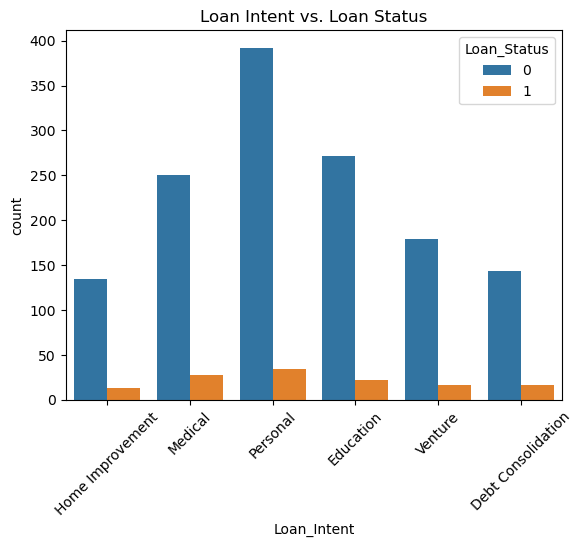

In [80]:
# Distribution of Loan Intent by Loan Status
sns.countplot(x='Loan_Intent', hue='Loan_Status', data=df)
plt.title('Loan Intent vs. Loan Status')
plt.xticks(rotation=45)

## Multivariate analysis

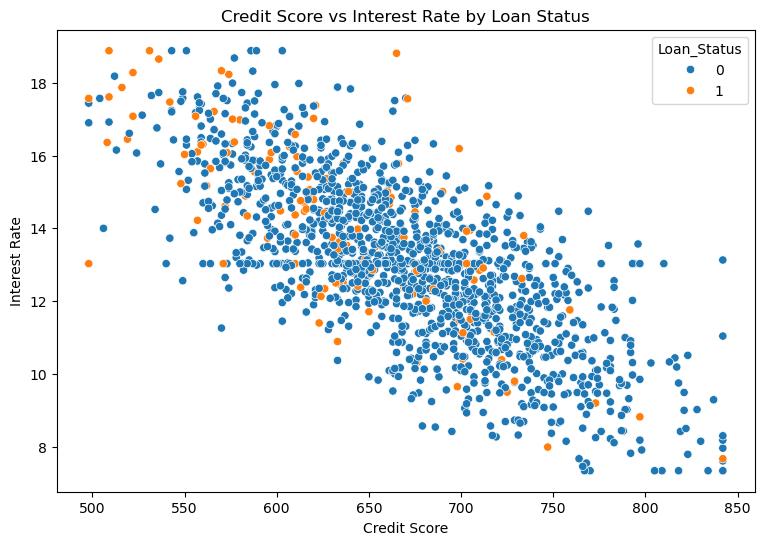

In [81]:
#Credit Score vs Interest Rate by Loan Status
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Credit_Score",
    y="Interest_Rate",
    hue="Loan_Status"
)

plt.title("Credit Score vs Interest Rate by Loan Status")
plt.xlabel("Credit Score")
plt.ylabel("Interest Rate")

plt.show()

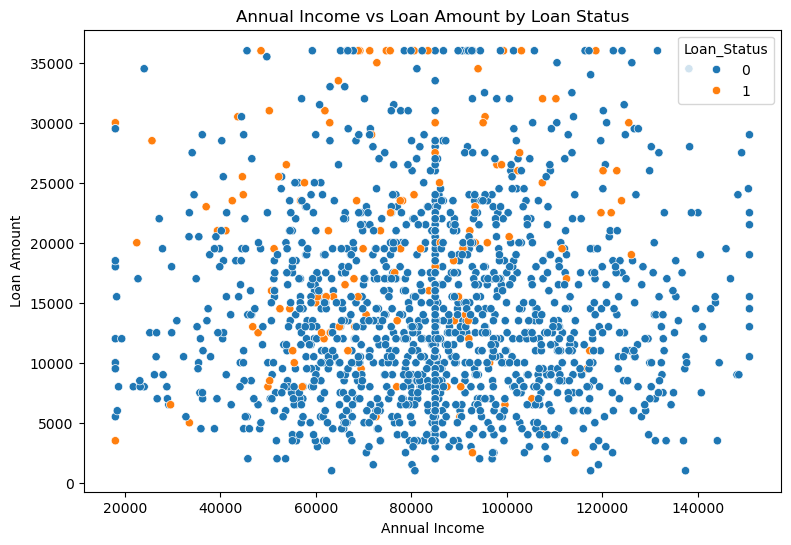

In [82]:
#Annual Income vs Loan Amount by Loan Status
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Annual_Income",
    y="Loan_Amount",
    hue="Loan_Status"
)

plt.title("Annual Income vs Loan Amount by Loan Status")
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")

plt.show()

In [83]:
corr_matrix = df[num_cols].corr()

corr_matrix

,Age,Annual_Income,Employment_Length_Yrs,Credit_Score,Debt_To_Income_Ratio,Loan_Amount,Interest_Rate,Loan_Status
Age,1.000000,0.418435,0.039256,-0.073599,0.006392,0.014669,0.051423,-0.059625
Annual_Income,0.418435,1.000000,0.040526,-0.067024,0.000420,0.016427,0.071929,-0.098471
Employment_Length_Yrs,0.039256,0.040526,1.000000,0.010366,-0.014656,-0.023292,0.009528,0.017631
Credit_Score,-0.073599,-0.067024,0.010366,1.000000,0.045927,-0.025404,-0.742855,-0.171905
Debt_To_Income_Ratio,0.006392,0.000420,-0.014656,0.045927,1.000000,0.063112,-0.023096,0.147849
Loan_Amount,0.014669,0.016427,-0.023292,-0.025404,0.063112,1.000000,0.040235,0.206268
Interest_Rate,0.051423,0.071929,0.009528,-0.742855,-0.023096,0.040235,1.000000,0.149533
Loan_Status,-0.059625,-0.098471,0.017631,-0.171905,0.147849,0.206268,0.149533,1.000000


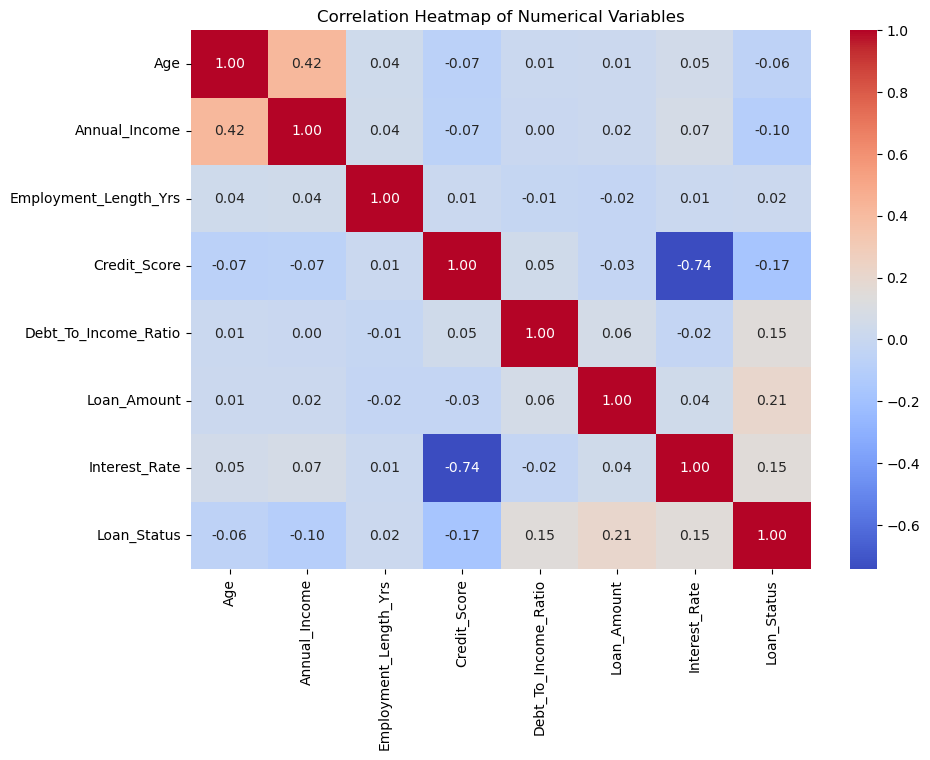

In [84]:
plt.figure(figsize=(10,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

In [85]:
df[num_cols].skew()


Age                      0.010523
Annual_Income           -0.043248
Employment_Length_Yrs    1.099544
Credit_Score             0.039747
Debt_To_Income_Ratio     0.493025
Loan_Amount              0.757923
Interest_Rate           -0.012061
Loan_Status              2.941199
dtype: float64

In [86]:
df["Age"].skew()

np.float64(0.010522886015245078)

In [87]:
df.to_csv("Loan_Default_cleaned.csv", index = False)